# FPL Squad Optimizer - Dashboard

This notebook uses the refactored `fpl_engine` modules to run the sequential transfer planning and optimization pipeline.

In [1]:
%pip install optuna optunahub
%pip install -r https://hub.optuna.org/samplers/auto_sampler/requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Run this if you are in Google Colab to mount your drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys
    sys.path.append('/content/drive/My Drive/Hobby/FPL')
except ImportError:
    pass  # Not running in Colab

In [3]:
import asyncio
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

from fpl_engine.config import (
    MY_FPL_ID, get_season_params,
)
from fpl_engine.data import (
    get_current_players_df, fetch_raw_history_cache,
    get_team_df, get_pos_constraint_df,
    get_current_gameweek, get_max_finished_gameweek,
    get_fpl_gameweek_data, get_my_player_ids,
    get_dynamic_weights,
)
from fpl_engine.features import (
    compute_rolling_team_ratings, blend_team_ratings,
    get_fixture_players_stats_df, compute_global_z_distributions,
)
from fpl_engine.scoring import (
    _fit_bonus_multinomial, _fit_regression_params,
    _calculate_performance_indices, create_optimized_custom_score,
)
from fpl_engine.solver import plan_sequential_transfers

## 1. Configuration

In [4]:
bank_values = 1.1
current_free_transfer_avaliable = 1
default_horizon = 3

max_diff_weight = 0.13
max_upside_weight = 0.12

current_realizable_value_dict = {
      # GKP
      139: 4.5, 736: 5.6,
      # DEF
      5: 6.9, 77: 4.0, 151: 4.5, 256: 5.8, 343: 4.3,
      # MID
      82: 8.1, 235: 10.4, 237: 6.5, 449: 9.9, 457: 5.7,
      # FWD
      100: 4.6, 136: 7.2, 430: 14.3
}


## 2. Fetch Data & Build Features

In [5]:
# 1. Fetch Base Data
current_gw = get_current_gameweek()
data_gameweek = get_max_finished_gameweek()
fpl_team_df = get_team_df()
players_df = get_current_players_df()

# 2. Season-Adaptive Params (interpolated for current GW)
params = get_season_params(current_gw)

print(f"Current Gameweek: {current_gw}")
print(f"Max Finished GW:  {data_gameweek}")

# 3. Fetch Match History (Async)
active_player_ids = players_df[players_df['minutes'] > 0]['id'].tolist()
raw_history_df = await fetch_raw_history_cache(active_player_ids, use_cache=True)

Current Gameweek: 36
Max Finished GW:  36
Loading raw match history from raw_history_cache.parquet (Age: 10.1 hours)...


In [14]:
from fpl_engine.tuning import auto_tune_if_needed
from fpl_engine.config import get_season_params

# 1. Trigger the automated tuning pipeline
# Set force=True if you want to run it immediately regardless of staleness
await auto_tune_if_needed(current_gw, force=False)

# 2. Reload parameters to ensure we are using the newly tuned values
params = get_season_params(current_gw)
print("Parameters loaded and ready.")



[2026-05-15 22:53:48] Auto-Tune Triggered: GW gap=35, stale (134d since last tune)
Starting FPL Engine Parameter Tuning (Extracted from Notebook)...
Loading raw match history from raw_history_cache.parquet (Age: 10.2 hours)...
   bps    P(0)    P(1)    P(2)    P(3)  E(bonus)
     0   1.000   0.000   0.000   0.000     0.000
     5   1.000   0.000   0.000   0.000     0.000
    10   0.999   0.001   0.000   0.000     0.001
    15   0.994   0.005   0.001   0.000     0.007
    20   0.966   0.028   0.006   0.001     0.041
    25   0.810   0.126   0.052   0.012     0.267
    30   0.350   0.289   0.250   0.111     1.123
    35   0.050   0.219   0.398   0.333     2.014
    40   0.004   0.092   0.351   0.553     2.453
    50   0.000   0.009   0.151   0.840     2.831
    60   0.000   0.001   0.049   0.951     2.950
    70   0.000   0.000   0.014   0.986     2.986


/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarn

Phase 1: Minutes Optimization...
GKP: scale=0.797  intercept=3.984  R²=0.305  n=657
DEF: scale=0.972  intercept=6.992  R²=0.465  n=2765
MID: scale=0.996  intercept=6.685  R²=0.409  n=3145
FWD: scale=1.011  intercept=0.962  R²=0.751  n=701


/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/fpl_engine/tuning.py:244: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner_p1 = optuna.pruners.PatientPruner(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


GKP: scale=0.797  intercept=3.984  R²=0.305  n=657
DEF: scale=0.972  intercept=6.992  R²=0.465  n=2765
MID: scale=0.996  intercept=6.685  R²=0.409  n=3145
FWD: scale=1.011  intercept=0.962  R²=0.751  n=701
GKP: scale=0.797  intercept=3.984  R²=0.305  n=657
DEF: scale=0.972  intercept=6.992  R²=0.465  n=2765
MID: scale=0.996  intercept=6.685  R²=0.409  n=3145
FWD: scale=1.011  intercept=0.962  R²=0.751  n=701


...

/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarn

GKP: scale=0.309  intercept=10.301  R²=0.069  n=657
DEF: scale=0.412  intercept=10.343  R²=0.151  n=2765
MID: scale=0.625  intercept=10.277  R²=0.223  n=3145
FWD: scale=0.230  intercept=11.506  R²=0.200  n=701
GKP: scale=0.263  intercept=11.051  R²=0.058  n=657
DEF: scale=0.403  intercept=10.744  R²=0.154  n=2765
MID: scale=0.673  intercept=9.919  R²=0.250  n=3145
FWD: scale=0.221  intercept=11.604  R²=0.205  n=701
GKP: scale=0.365  intercept=9.371  R²=0.092  n=657
DEF: scale=0.434  intercept=9.916  R²=0.167  n=2765
MID: scale=0.681  intercept=9.880  R²=0.260  n=3145
FWD: scale=0.219  intercept=11.635  R²=0.208  n=701
GKP: scale=0.297  intercept=10.499  R²=0.066  n=657
DEF: scale=0.411  intercept=10.431  R²=0.153  n=2765
MID: scale=0.668  intercept=9.948  R²=0.247  n=3145
FWD: scale=0.223  intercept=11.592  R²=0.204  n=701
GKP: scale=0.736  intercept=2.424  R²=0.279  n=657
DEF: scale=0.547  intercept=7.503  R²=0.218  n=2765
MID: scale=0.675  intercept=9.908  R²=0.252  n=3145
FWD: scale

/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarn

GKP: scale=0.427  intercept=8.338  R²=0.113  n=657
DEF: scale=0.447  intercept=9.594  R²=0.168  n=2765
MID: scale=0.683  intercept=9.870  R²=0.266  n=3145
FWD: scale=0.217  intercept=11.660  R²=0.209  n=701
GKP: scale=0.294  intercept=10.551  R²=0.065  n=657
DEF: scale=0.410  intercept=10.460  R²=0.152  n=2765
MID: scale=0.665  intercept=9.972  R²=0.244  n=3145
FWD: scale=0.223  intercept=11.584  R²=0.203  n=701

Stopping early: No improvement in the last 15 trials.

--- ENSEMBLE AVERAGING (Top 5 Trials) ---
Best Score: 0.2198
Tuning complete in 166.40s. Parameters updated in tuned_params.json
Parameters loaded and ready.


/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarn

In [6]:
# 4. Compute Team Ratings & Blends
rolling_ratings_raw, latest_ratings_raw = compute_rolling_team_ratings(
    raw_history_df,
    ema_alpha    = params.get('rolling_ema_alpha', 0.15),
    min_fixtures = 3,
)

team_ratings_df, latest_team_ratings = blend_team_ratings(
    rolling_ratings_raw,
    latest_ratings_raw,
    fpl_team_df,
    league_avg_xG           = params.get('league_avg_xG',            1.45),
    league_avg_xGC          = params.get('league_avg_xGC',           1.45),
    blend_alpha             = params.get('blend_alpha',              0.75),
    min_fixtures_full_trust = params.get('min_fixtures_full_trust',  10),
)

# 5. Generate Fixture Specific Projections
global_dists = compute_global_z_distributions(team_ratings_df)

fixture_player_df = get_fixture_players_stats_df(
    params,
    raw_history_df,
    global_dists,
    team_ratings_df    = team_ratings_df,
    latest_team_ratings= latest_team_ratings,
)

## 3. Generate Scoring Projections

In [7]:
# 1. Fit Models & Inject Regression Weights
reg_params  = _fit_regression_params(fixture_player_df)
bonus_model = _fit_bonus_multinomial(raw_history_df)
params.update(reg_params)

# 2. Calculate Performance Indices
fixture_player_df = _calculate_performance_indices(
    fixture_player_df,
    params,
    bonus_model=bonus_model
)

GKP: scale=0.645  intercept=5.894  R²=0.224  n=759
DEF: scale=0.974  intercept=6.926  R²=0.459  n=3208
MID: scale=1.016  intercept=6.595  R²=0.412  n=3622
FWD: scale=1.032  intercept=0.792  R²=0.761  n=829


/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/jubilee/Library/CloudStorage/GoogleDrive-z.jubilee.z@gmail.com/My Drive/Hobby/FPL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [8]:
# 3. Aggregate to per-GW projections (sum scoring, mean rates)
grouping_columns = [
    'gameweek', 'id_player', 'now_cost', 'selected_by_percent',
    'web_name', 'position', 'team_name'
]

sum_columns = [
    'Perf_IDX', 'ceiling_score', 'GOAL_INDEX', 'ASSIST_INDEX',
    'CLEAN_SHEET_INDEX', 'bonus_component', 'defcon_component',
    'minutes_IDX', 'actual_minutes'
]

mean_columns = [
    'recent_minutes_form', 'finishing_factor', 'protective_factor',
    'fixture_attack_multiplier', 'fixture_defence_multiplier',
    'fixture_calibrated_points',
    'start_per_gameplayed', 'consecutive_start_streak', 'hybrid_bps_abs', 'score_std',
]

# Build agg_dict: only include columns that actually exist
agg_dict = {col: 'sum' for col in sum_columns if col in fixture_player_df.columns}
agg_dict.update({col: 'mean' for col in mean_columns if col in fixture_player_df.columns})

# Only use grouping columns that exist
valid_grouping = [c for c in grouping_columns if c in fixture_player_df.columns]

gw_projection_df = fixture_player_df.groupby(valid_grouping).agg(agg_dict).reset_index()

print(f"Aggregated: {len(fixture_player_df)} fixture rows -> {len(gw_projection_df)} GW projection rows")

Aggregated: 33344 fixture rows -> 31429 GW projection rows


Mode: PUSH 🟠  (15.3% from target)  |  Diff: 0.2080  |  Upside: 0.1632

=== DYNAMIC MAPPING SUMMARY TABLE ===


,Avg_Perf_IDX,Avg_Custom_Score,Avg_Gap_Ratio,Avg_Dynamic_Upside,Avg_Score_Std,Smoothed_CV,Diff_Final_Weight
DEF,2.60,2.96,0.761,0.148,1.411,1.501,0.193
FWD,2.01,2.35,0.913,0.157,1.262,1.993,0.256
GKP,4.35,4.79,0.701,0.142,1.925,1.139,0.146
MID,2.21,2.55,0.837,0.151,1.276,1.761,0.226


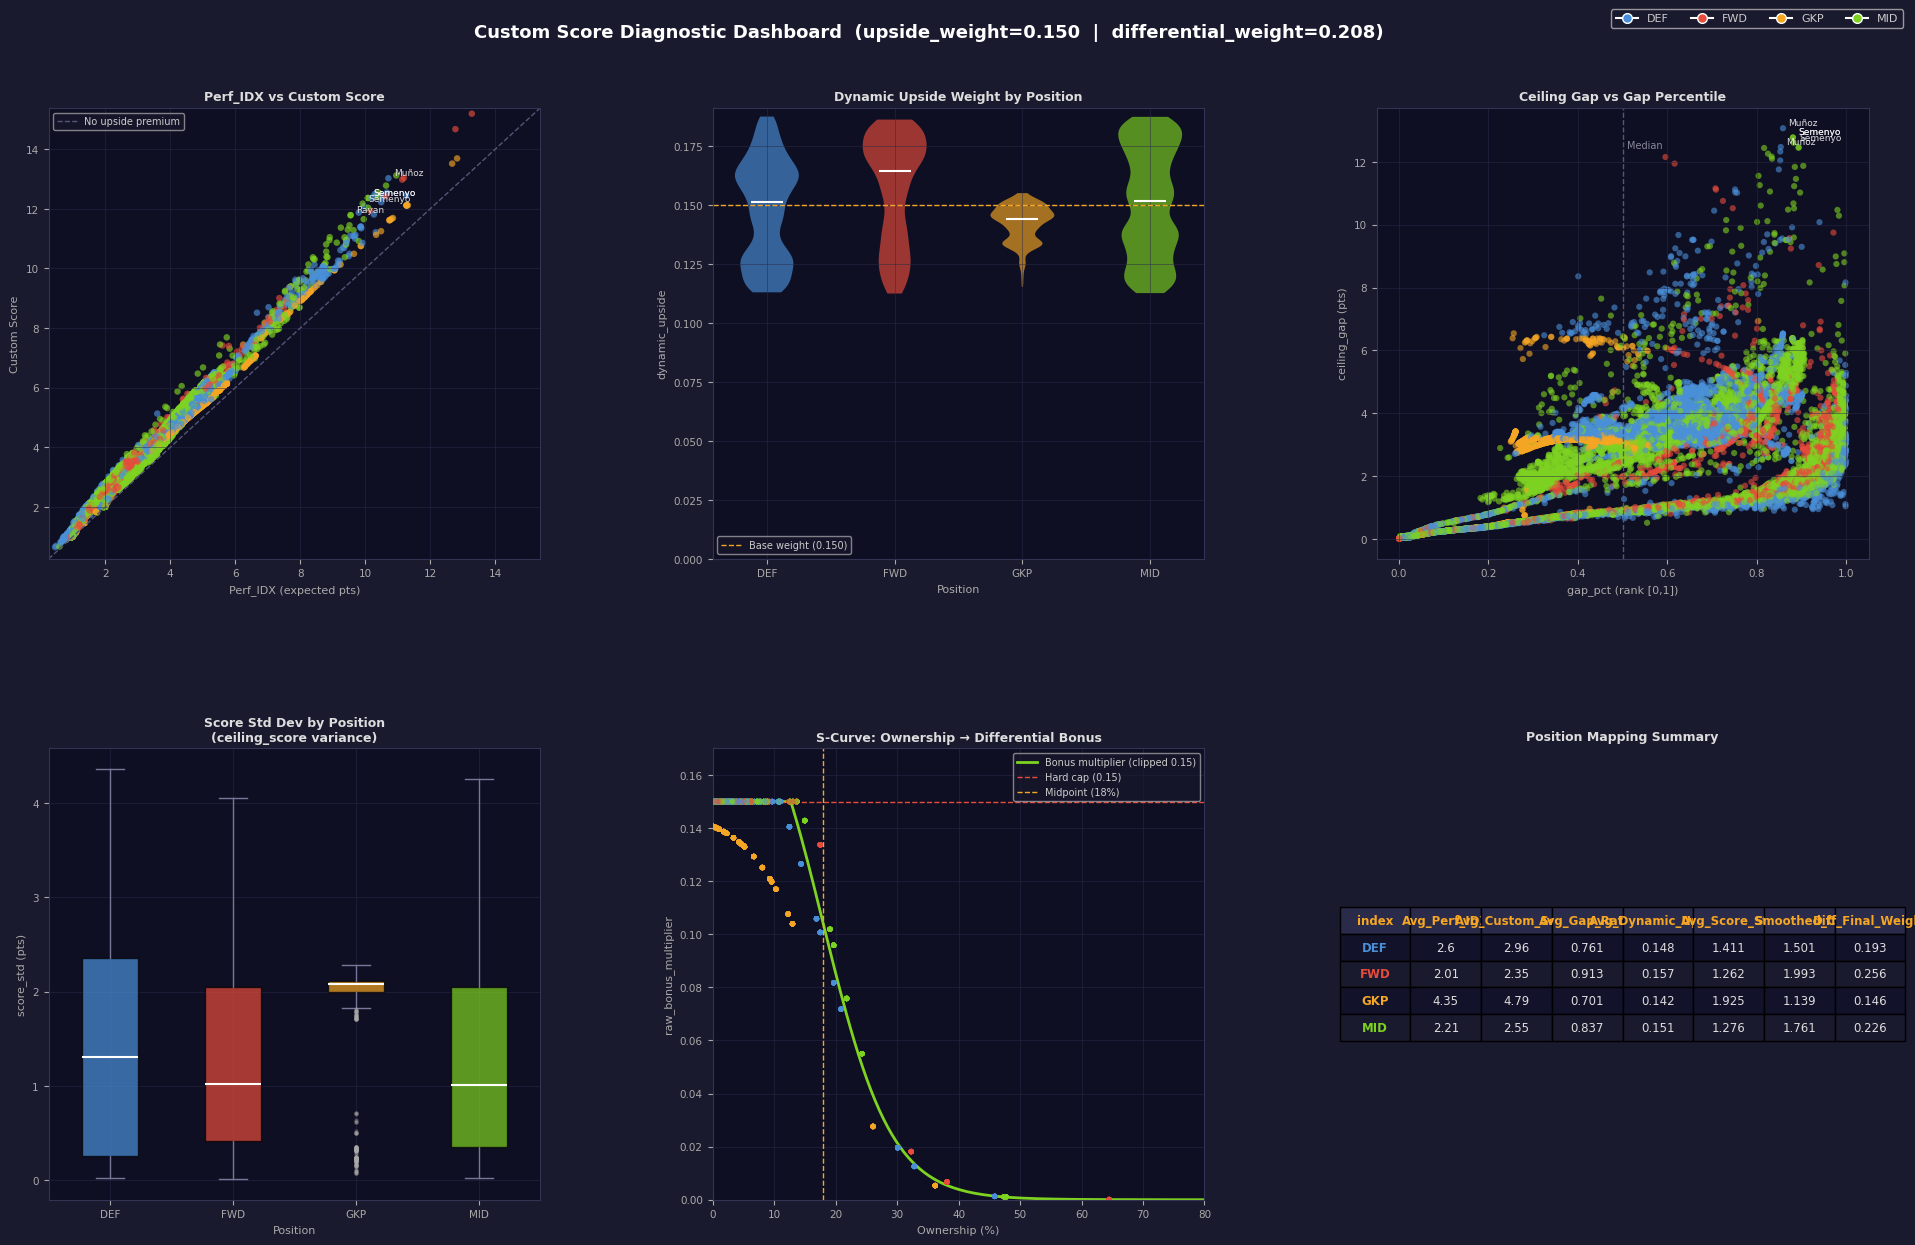

In [9]:
# 4. Dynamic Weights & Custom Score
try:
    fpl_gameweek_data = get_fpl_gameweek_data(MY_FPL_ID)
    weights = get_dynamic_weights(fpl_gameweek_data, data_gameweek,
                                  max_diff_weight=max_diff_weight,
                                  max_upside_weight=max_upside_weight)
    diff_weight   = weights['diff_weight']
    upside_weight = weights['upside_weight']
    print(f"Mode: {weights['mode']}  |  Diff: {diff_weight:.4f}  |  Upside: {upside_weight:.4f}")
except Exception as e:
    print(f"Weight fetch failed: {e} -- using max weights")
    diff_weight   = max_diff_weight
    upside_weight = max_upside_weight

gw_projection_df = create_optimized_custom_score(
    df=gw_projection_df,
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    visualize=True
)

## 4. Projection Rankings

In [10]:
projection_group = ['id_player', 'now_cost', 'selected_by_percent', 'web_name',
       'position', 'team_name', ]
avg_columns = list(set(list(agg_dict.keys()) + ['custom_score', 'ceiling_score', 'dynamic_upside']))
# Only keep columns that exist
avg_columns = [c for c in avg_columns if c in gw_projection_df.columns]

display_columns = [
    'id_player', 'now_cost', 'selected_by_percent', 'web_name', 'position',
    'team_name', 'minutes_IDX', 'Perf_IDX', 'ceiling_score',
    'GOAL_INDEX', 'ASSIST_INDEX', 'CLEAN_SHEET_INDEX', 'bonus_component',
    'defcon_component', 'finishing_factor', 'fixture_attack_multiplier',
    'protective_factor', 'fixture_defence_multiplier',
]
display_columns = [c for c in display_columns if c in gw_projection_df.columns]

In [11]:
N = 15

# 1. Define the custom sorting order
pos_order = ['GKP', 'DEF', 'MID', 'FWD']

# 2. Filter and Process
top_n_df = gw_projection_df[gw_projection_df['gameweek'] >= current_gw+1].copy()
top_n_df = top_n_df.groupby(projection_group)[avg_columns].mean().reset_index()

# Convert position to a categorical type so it sorts correctly
top_n_df['position'] = pd.Categorical(top_n_df['position'], categories=pos_order, ordered=True)

# --- Safely combine columns without creating duplicates ---
final_cols = ['position', 'custom_score'] + display_columns
final_cols = list(dict.fromkeys(final_cols))
final_cols = [c for c in final_cols if c in top_n_df.columns]

# 3. Apply grouping and selection
result = (top_n_df
          .sort_values(['position', 'custom_score'], ascending=[True, False])
          .groupby('position', observed=True)
          .head(N)
          )[final_cols]

# 4. Print as a clean string
print(f"--- Top {N} Projections from GW{current_gw+1} + ---")
for pos in pos_order:
    pos_data = result[result['position'] == pos].round(3)
    print(f"\n== {pos} ==")
    if pos_data.empty:
        print("No data found.")
    else:
        print(pos_data.drop(columns=['position']).to_string(index=False))

--- Top 15 Projections from GW37 + ---

== GKP ==
 custom_score  id_player  now_cost  selected_by_percent      web_name      team_name  minutes_IDX  Perf_IDX  ceiling_score  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component  finishing_factor  fixture_attack_multiplier  protective_factor  fixture_defence_multiplier
        6.694        183       4.2                  0.1         Weiss        Burnley       85.522     6.284          9.408       0.000         0.000              2.666            0.071               0.0             0.944                      1.030              1.007                       0.866
        6.141        812       4.0                  0.1       Ellborg     Sunderland       90.000     5.731          8.817       0.000         0.011              2.620            0.039               0.0             0.944                      0.939              0.948                       0.983
        6.060        254       3.9                  0.3       Ben

## 5. Sequential Transfer Planner

In [12]:
MY_CURRENT_TEAM_IDS = get_my_player_ids(MY_FPL_ID, current_gw)
locked_values = sum(current_realizable_value_dict.values()) + bank_values

print(f"My Net Transfer Value : {locked_values:.1f} M")
print(f"Bank : {bank_values:.1f} M")

plan_sequential_transfers(
    gw_projection_df = gw_projection_df,
    current_team_ids = MY_CURRENT_TEAM_IDS,
    start_gameweek = current_gw + 1,
    planning_horizon = default_horizon,
    initial_free_transfers = current_free_transfer_avaliable,
    current_realizable_value_dict = current_realizable_value_dict,
    bank_balance = bank_values,

    ft_value = 1.23,
    bench_factor = 1e-4,

    objective_column = 'custom_score',
    captain_column = 'captain_idx',

    # WC_WEEK = 24,
    # FH_WEEK = 34,
    # BB_WEEK = 33,
    # TC_WEEK = 26,

    fixed_player_dict = {
        'Default':[],
    },
    banned_player_dict = {
        'Default':[183, 221, 367],
    },
)

Successfully fetched your team IDs for Gameweek 36:
[736, 256, 5, 151, 82, 488, 235, 449, 136, 100, 430, 139, 457, 77, 343]
My Net Transfer Value : 103.4 M
Bank : 1.1 M

--- Running Sequential Transfer Planner for GW37 ---

Optimal Sequential Transfer Plan Found!
Projected Total Utility: 145.56

==================== Plan for Gameweek 37 ====================
Free Transfers Available: 1
Transfers Made: 1 (Hits Cost: 0)

--> OUT:
 id_player   web_name team_name position  now_cost  custom_score  captain_idx  selected_by_percent  minutes_IDX  fixture_attack_multiplier  fixture_defence_multiplier  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component
       736 Donnarumma  Man City      GKP       5.6         4.653        6.427                  9.3         90.0                      1.069                       1.062       0.001         0.011              1.849            0.007               0.0

<-- IN:
 id_player web_name  team_name position  now_cost  custom_score  c